# Feishu Quant Competition - OOS Submission Generator

Generates the one-shot OOS trade file `TEAMID_sell_open.csv` for D485-D726.

**Design / compliance notes**
- **Inputs are sorted by `trade_day_id`** before anything else (Section 1 cells assert this).
- **Factors/alpha** are computed on the full IS+OOS history so day-t look-backs are correct, but every
  fitted artifact stays IS-only: the `BaseAlpha` factor weights are derived on **IS data only** (forward
  returns masked so the 10-day window never crosses into OOS); the sector clustering is hard-restricted
  to D080-D240; the walk-forward Ridge trains only on past-only data (12-day purge).
- **`BaseAlpha` is the raw alpha** - a cross-sectional z-score blend of the factors that the IS-only
  `blend` routine selects and weights (each weight proportional to its signed IS IC-IR). It is then
  sector-residualised and ensembled with the walk-forward Ridge to form `alpha_final`. No weight is
  initialised by hand; whatever `blend` returns is used directly.
- **Portfolio starts flat with RMB 50M on D485** (per Section 4.1 - the official engine evaluates the
  submitted orders from a 50M cold start), builds the book on D485 and trades to D726.
- An **independent official-rules replay** re-prices the written CSV from scratch (T+1, fees, lot
  shrink-to-fit, full-liquidation) and confirms it reproduces the strategy NAV to ~0 relative error,
  and that EOD holdings >= 10 every day.

**Data sources (the only inputs):** `daily_data_in_sample.parquet`,
`daily_data_release_stage_out_of_sample.parquet`, `lob_data_in_sample.parquet`,
`lob_data_release_stage_out_of_sample.parquet`. The 10-min LOB is aggregated to daily factors
in-memory on every run.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
DAILY_PATH = ROOT/'daily_data_in_sample.parquet'

# ===================== PRODUCTION CONFIG =====================
# All hyperparameters below were selected using in-sample analysis and fixed before out-of-sample evaluation.

# Portfolio construction
USE_AGGRESSIVE_CONC = True       # concentrated book
CONC_N_TARGET       = 12        # target holdings: IS-selected balance of diversification, stability and signal concentration
CONC_NAME_CAP       = 0.09        # per-name cap: bounds single-name gap risk in a concentrated book
CONC_MIN_HOLDINGS   = 10
USE_ALPHA_RANK_SIZE = True       # weights = 0.5*inv_vol + 0.5*alpha_rank
ALPHA_RANK_BLEND    = 0.50
STICKY_TOP_K        = 50
REBAL_EVERY         = 10
AMT_MIN             = 300_000.0

# Alpha
USE_SECTOR_RESID    = True
SECTOR_RESID_LAMBDA = 0.50        # partial sector-mean removal
N_CLUSTERS_SEC      = 10
ENS_RIDGE_W         = 0.20        # weight on the ridge-5d signal in the ensemble (20% chosen on IS: enough to add decorrelated ML signal without destabilising the base)
RIDGE_ALPHA_REG     = 10.0
RIDGE_HORIZON       = 5
ML_RETRAIN          = 30        # Ridge retrain interval (days): adapts to drift while staying stable/cheap
ML_PURGE            = 12        # purge gap (days) > RIDGE_HORIZON so no training label overlaps the prediction day (anti-leakage)

# Risk overlay
VOL_TARGET_ANN   = 0.18        # annual vol target: IS-calibrated, trades CAGR against the drawdown score term
VOL_SCALE_LOW    = 0.90
VOL_SCALE_HIGH   = 1.10
USE_BREADTH_GROSSUP = True
BREADTH_HI       = 0.55
BREADTH_GROSS_HI = 1.20
DD_BREAKER       = -0.05        # drawdown breaker: cut gross when >5% below peak to defend the MaxDD score term
DD_COOL_DAYS     = 3
GROSS_FLOOR_DD   = 0.50

# Execution (rule-bound)
SELL_MODE   = 'open'              
INITIAL_CAPITAL = 50_000_000.0
FEE_BPS_BUY = 1e-4; FEE_BPS_SELL = 6e-4; MIN_FEE = 5.0
LOT = 100; WARMUP_DAY = 80; TRADING_DAYS_YR = 252; ML_HORIZON = 10

DAILY_FACTORS = ['REV_1','REV_3','REV_5','REV_10','REV_20','MOM_60_20','LOWVOL','ILLIQ',
                 'OVNT','MORN_REV','INTRA_MOM','RANGE_PCT','CLOSE_STRENGTH','RANGE_TREND','SKEW_60','AMT_GROWTH_5']
LOB_OLD = ['OFI_D','DWI_D','SPR_D','DWI10_D','OFI_LAST4','OFI_TREND']
LOB_NEW = ['OFI_RANGE','MIDPRICE_VOL','BOOK_TIGHTNESS','DWI_AFT_MORN','SPR_RANGE']
LOB_FACTORS = LOB_OLD + LOB_NEW
ALL_FACTORS = DAILY_FACTORS + LOB_FACTORS
print('production config loaded.')

# ===================== OOS SUBMISSION CONFIG =====================
TEAM_ID = 'T025'                       
OOS_START_DAY = 485                      # D485 is the first OOS day (fresh 50M start)
DAILY_OOS_PATH = ROOT/'daily_data_release_stage_out_of_sample.parquet'
LOB_OOS_RAW    = ROOT/'lob_data_release_stage_out_of_sample.parquet'
LOB_RAW_IS     = ROOT/'lob_data_in_sample.parquet'
SUBMISSION_CSV = ROOT/f'{TEAM_ID}_sell_{SELL_MODE}.csv'

print('OOS submission config loaded. Output file ->', SUBMISSION_CSV.name)


production config loaded.
OOS submission config loaded. Output file -> T025_sell_open.csv


## 1. Load + sort the OOS data by `trade_day_id`, concat with in-sample

In [2]:
daily_is  = pl.read_parquet(DAILY_PATH)
daily_oos = pl.read_parquet(DAILY_OOS_PATH)
assert daily_is.columns == daily_oos.columns, 'IS/OOS daily schema mismatch'

def is_day_sorted(df):
    dd = df['trade_day_id'].to_list()
    return dd == sorted(dd, key=lambda s: int(s[1:]))

# --- requirement: ensure both inputs are sorted ascending by trade_day_id ---
oos_days = sorted(daily_oos['trade_day_id'].unique().to_list(), key=lambda s: int(s[1:]))
assert oos_days[0]=='D485' and oos_days[-1]=='D726' and len(oos_days)==242, ('unexpected OOS day range', oos_days[:1], oos_days[-1:], len(oos_days))
daily_is  = daily_is.sort(['trade_day_id','asset_id'])
daily_oos = daily_oos.sort(['trade_day_id','asset_id'])
print('OOS daily sorted ascending by trade_day_id :', is_day_sorted(daily_oos))
print('IS  daily sorted ascending by trade_day_id :', is_day_sorted(daily_is))

# the factor pipeline needs (asset_id, trade_day_id) order for per-asset rolling ops
daily = pl.concat([daily_is, daily_oos]).sort(['asset_id','trade_day_id'])
all_days = sorted(daily['trade_day_id'].unique().to_list(), key=lambda s: int(s[1:]))
assert all_days[0]=='D001' and all_days[-1]=='D726' and len(all_days)==726, 'concat day span wrong'
print('daily concatenated:', daily.height, 'rows |', daily['trade_day_id'].n_unique(), 'days |', daily['asset_id'].n_unique(), 'assets')

OOS daily sorted ascending by trade_day_id : True
IS  daily sorted ascending by trade_day_id : True
daily concatenated: 1606720 rows | 726 days | 2306 assets


## 2. LOB daily factors - computed in-memory from the raw 10-min book (no cache)

The raw book is sorted by `(asset_id, trade_day_id, time)` inside the builder, aggregated to the 11
daily LOB factors with the identical formulas for IS and OOS, then concatenated. Nothing is cached
to disk - the only data inputs are the four raw parquet files.

In [3]:
def dwi_expr(n_levels):
    parts = []
    for k in range(1, n_levels + 1):
        parts.append((1.0/k)*(pl.col(f'bid_volume_{k}')-pl.col(f'ask_volume_{k}'))/
                     (pl.col(f'bid_volume_{k}')+pl.col(f'ask_volume_{k}')).clip(lower_bound=1.0))
    return pl.sum_horizontal(parts)

def build_lob_daily(raw_path):
    q = (pl.scan_parquet(raw_path)
        .sort(['asset_id','trade_day_id','time'])
        .with_columns([
            pl.col('asset_id').cum_count().over(['asset_id','trade_day_id']).alias('snap_idx'),
            ((pl.col('bid_volume_1')-pl.col('ask_volume_1'))/(pl.col('bid_volume_1')+pl.col('ask_volume_1')).clip(lower_bound=1.0)).alias('ofi_s'),
            dwi_expr(5).alias('dwi5_raw'),
            dwi_expr(10).alias('dwi10_raw'),
            (((pl.col('ask_price_1')-pl.col('bid_price_1'))/((pl.col('ask_price_1')+pl.col('bid_price_1'))*0.5).clip(lower_bound=1e-6))).alias('spr_s'),
            ((pl.col('ask_price_1')+pl.col('bid_price_1'))*0.5).alias('mid_s'),
            ((pl.col('ask_price_5')-pl.col('bid_price_5'))/(pl.col('ask_price_1')-pl.col('bid_price_1')).clip(lower_bound=1e-6)).alias('tight_s'),
        ])
        .group_by(['asset_id','trade_day_id'])
        .agg([
            pl.col('ofi_s').mean().alias('OFI_D'),
            pl.col('dwi5_raw').mean().alias('DWI_D'),
            pl.col('dwi10_raw').mean().alias('DWI10_D'),
            (-pl.col('spr_s').mean()).alias('SPR_D'),
            pl.col('ofi_s').filter(pl.col('snap_idx') <= 4).mean().alias('OFI_FIRST4'),
            pl.col('ofi_s').filter(pl.col('snap_idx') >= 21).mean().alias('OFI_LAST4'),
            (pl.col('ofi_s').max()-pl.col('ofi_s').min()).alias('OFI_RANGE'),
            (pl.col('mid_s').std()/pl.col('mid_s').mean().clip(lower_bound=1e-6)).alias('MIDPRICE_VOL'),
            pl.col('tight_s').mean().alias('BOOK_TIGHTNESS'),
            (pl.col('dwi5_raw').filter(pl.col('snap_idx') > 12).mean()-pl.col('dwi5_raw').filter(pl.col('snap_idx') <= 12).mean()).alias('DWI_AFT_MORN'),
            (pl.col('spr_s').max()-pl.col('spr_s').min()).alias('SPR_RANGE'),
        ])
        .with_columns([(pl.col('OFI_LAST4')-pl.col('OFI_FIRST4')).alias('OFI_TREND')]))
    try:
        return q.collect(engine='streaming')
    except Exception as e:
        print('  streaming failed:', e, '-> in-memory collect'); return q.collect()

# LOB daily factors are computed directly from the raw 10-min book.
print('building IS LOB daily factors'); lob_is = build_lob_daily(LOB_RAW_IS)
print('  IS  LOB daily:', lob_is.height, 'rows')
print('building OOS LOB daily factors'); lob_oos = build_lob_daily(LOB_OOS_RAW)
print('  OOS LOB daily:', lob_oos.height, 'rows')

lob_oos = lob_oos.select(lob_is.columns)
lob_daily = pl.concat([lob_is, lob_oos])
_ld = sorted(lob_daily['trade_day_id'].unique().to_list(), key=lambda s: int(s[1:]))
print('full LOB daily:', lob_daily.height, 'rows | days', len(_ld), _ld[0], '->', _ld[-1])

building IS LOB daily factors
  IS  LOB daily: 1061536 rows
building OOS LOB daily factors
  OOS LOB daily: 548014 rows
full LOB daily: 1609550 rows | days 726 D001 -> D726


## 3. Daily factors (production pipeline)

In [4]:
d = daily.with_columns([(pl.col('close')*pl.col('adj_factor')).alias('adj_close')])
d = d.with_columns([pl.col('adj_close').pct_change().over('asset_id').alias('ret_d'),
                    pl.col('amount').rolling_median(window_size=20,min_samples=10).over('asset_id').alias('amt_med20')])
d = d.with_columns([(pl.col('ret_d').abs()/pl.col('amount').clip(lower_bound=1.0)).alias('illiq_d'), pl.col('volume').log1p().alias('log_vol')])
d = d.with_columns([(-(pl.col('adj_close')/pl.col('adj_close').shift(1).over('asset_id')-1.0)).alias('REV_1'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(3).over('asset_id')-1.0)).alias('REV_3'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(5).over('asset_id')-1.0)).alias('REV_5'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(10).over('asset_id')-1.0)).alias('REV_10'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(20).over('asset_id')-1.0)).alias('REV_20')])
d = d.with_columns([(pl.col('adj_close').shift(20).over('asset_id')/pl.col('adj_close').shift(60).over('asset_id')-1.0).alias('MOM_60_20'),
                    (-pl.col('ret_d').rolling_std(window_size=20,min_samples=15).over('asset_id')).alias('LOWVOL'),
                    (-pl.col('illiq_d').rolling_mean(window_size=20,min_samples=15).over('asset_id')).alias('ILLIQ')])
d = d.with_columns([(-(pl.col('open')/pl.col('close').shift(1).over('asset_id')-1.0)).alias('OVNT'),
                    (-(pl.col('vwap_0930_0935')/pl.col('open').clip(lower_bound=1e-6)-1.0)).alias('MORN_REV'),
                    (pl.col('close')/pl.col('vwap_0930_0935').clip(lower_bound=1e-6)-1.0).alias('INTRA_MOM')])
d = d.with_columns([(-((pl.col('high')-pl.col('low'))/pl.col('close').clip(lower_bound=1e-6))).alias('RANGE_PCT'),
                    (-((pl.col('close')-pl.col('low'))/(pl.col('high')-pl.col('low')).clip(lower_bound=1e-6))).alias('CLOSE_STRENGTH')])
d = d.with_columns([pl.col('RANGE_PCT').rolling_mean(window_size=5,min_samples=3).over('asset_id').alias('_r5'),
                    pl.col('RANGE_PCT').rolling_mean(window_size=20,min_samples=10).over('asset_id').alias('_r20')])
d = d.with_columns([(pl.col('_r5')-pl.col('_r20')).alias('RANGE_TREND')]).drop(['_r5','_r20'])
d = d.with_columns([pl.col('ret_d').rolling_mean(window_size=60,min_samples=30).over('asset_id').alias('_mu60'),
                    pl.col('ret_d').rolling_std(window_size=60,min_samples=30).over('asset_id').alias('_sd60')])
d = d.with_columns([((pl.col('ret_d')-pl.col('_mu60'))**3).rolling_mean(window_size=60,min_samples=30).over('asset_id').alias('_m3')])
d = d.with_columns([(-(pl.col('_m3')/(pl.col('_sd60')**3).clip(lower_bound=1e-12))).alias('SKEW_60'),
                    (pl.col('amount')/pl.col('amount').shift(5).over('asset_id').clip(lower_bound=1.0)-1.0).alias('AMT_GROWTH_5')]).drop(['_mu60','_sd60','_m3'])
d = d.with_columns([((pl.col('close')/pl.col('close').shift(1).over('asset_id')-1.0)>0.095).alias('limit_up_prev'),
                    ((pl.col('volume')<=0)|(pl.col('volume').shift(1).over('asset_id')<=0)|(pl.col('volume').shift(2).over('asset_id')<=0)).alias('suspended_recent')])
print('daily factors done')

daily factors done


## 4. Merge LOB, lag 1 day, EMA-smooth, cross-sectional z-score (production pipeline)

In [5]:
drop_cols=[c for c in ['OFI_FIRST4'] if c in lob_daily.columns]
features = d.join(lob_daily.drop(drop_cols) if drop_cols else lob_daily, on=['asset_id','trade_day_id'], how='left')
# --- Leakage control: lag every factor by one trading day (shift(1)) ---
# A day-t decision may use information only through the close of t-1; lagging every
# factor enforces this causal boundary and removes look-ahead (forward-information) bias.
features = features.with_columns([pl.col(c).shift(1).over('asset_id').alias(c) for c in ALL_FACTORS])
# EMA-smooth the LOB factors (half-life 3 days)
ae = 1 - 0.5**(1/3)
features = features.with_columns([pl.col(c).ewm_mean(alpha=ae, adjust=False).over('asset_id').alias(c) for c in LOB_FACTORS])
def cs_z(col):
    q01=pl.col(col).quantile(0.01).over('trade_day_id'); q99=pl.col(col).quantile(0.99).over('trade_day_id')
    cl=pl.min_horizontal(pl.max_horizontal(pl.col(col),q01),q99); mu=cl.mean().over('trade_day_id'); sd=cl.std().over('trade_day_id')
    return ((cl-mu)/sd.clip(lower_bound=1e-9)).alias(f'z_{col}')
features = features.with_columns([cs_z(c) for c in ALL_FACTORS])
fdf = features.to_pandas().sort_values(['asset_id','trade_day_id']).reset_index(drop=True)
fdf['day_idx'] = fdf['trade_day_id'].str.slice(1).astype(int)
for h in [RIDGE_HORIZON, ML_HORIZON]:
    fdf[f'fwd_ret{h}']  = fdf.groupby('asset_id')['adj_close'].shift(-h)/fdf['adj_close'] - 1.0
    fdf[f'fwd_rank{h}'] = fdf.groupby('trade_day_id')[f'fwd_ret{h}'].rank(pct=True)
fdf['fwd_rank'] = fdf[f'fwd_rank{ML_HORIZON}']
print('feature frame:', fdf.shape)

feature frame: (1606720, 77)


## 5. `BaseAlpha` (raw alpha) - fit the factor weights on IS ONLY, from scratch

`BaseAlpha` is the **raw alpha**. The `blend` routine scores every candidate factor by its IC, IC-IR and
sub-period stability, drops the ones that fail the keep-filters, caps each factor family at two names,
keeps up to eight survivors and assigns each a weight proportional to its signed IC-IR. Running it on
IS+OOS would fit the weights using OOS forward returns - a rule violation - so it runs on an **IS-only**
frame whose 10-day forward-return target is masked so the window never reaches into OOS. Whatever weights
it returns are used directly to build `BaseAlpha`; nothing is compared against a hardcoded table.

In [6]:
ANCHOR=['z_LOWVOL','z_SPR_D','z_DWI_D','z_REV_5']; LI,LH,LIC,LC=0.010,0.20,0.12,0.65
FAMILY={'z_REV_1':'rev','z_REV_3':'rev','z_REV_5':'rev','z_REV_10':'rev','z_REV_20':'rev','z_OVNT':'intra','z_MORN_REV':'intra','z_INTRA_MOM':'intra','z_RANGE_PCT':'range','z_CLOSE_STRENGTH':'range','z_RANGE_TREND':'range','z_OFI_D':'lob','z_DWI_D':'lob','z_SPR_D':'lob','z_DWI10_D':'lob','z_OFI_LAST4':'lob','z_OFI_TREND':'lob','z_OFI_RANGE':'lob2','z_MIDPRICE_VOL':'mvol','z_BOOK_TIGHTNESS':'btight','z_DWI_AFT_MORN':'lob2','z_SPR_RANGE':'srange','z_LOWVOL':'risk','z_ILLIQ':'risk','z_MOM_60_20':'trend','z_SKEW_60':'moments','z_AMT_GROWTH_5':'flow'}

# IS-only fitting frame; forward returns recomputed within IS so they never peek into OOS
fdf_is = fdf[fdf['day_idx'] <= 484].copy()
fdf_is['fwd_ret_fit']  = fdf_is.groupby('asset_id')['adj_close'].shift(-ML_HORIZON)/fdf_is['adj_close'] - 1.0
fdf_is['fwd_rank_fit'] = fdf_is.groupby('trade_day_id')['fwd_ret_fit'].rank(pct=True)

def _ics(col, df, tgt):
    w=df[[col,tgt,'trade_day_id']].dropna(subset=[col,tgt])
    if w.empty: return pd.Series(dtype=float)
    return w.groupby('trade_day_id',sort=False).apply(lambda x:x[col].corr(x[tgt],method='spearman') if len(x)>=10 else np.nan).dropna()
def _fcorr_is(a,b):
    s=fdf_is[['trade_day_id',a,b]].dropna()
    if s.empty: return np.nan
    return s.groupby('trade_day_id',sort=False).apply(lambda x:x[a].corr(x[b],method='spearman') if len(x)>=20 else np.nan).dropna().mean()
def blend_is(cl,mx=8):
    rows=[]
    for c in cl:
        s=_ics(c,fdf_is,'fwd_rank_fit'); icf=s.mean() if len(s)>0 else np.nan; ist=s.std() if len(s)>0 else np.nan
        icir=icf/(ist+1e-9) if not pd.isna(icf) else np.nan
        h1=_ics(c,fdf_is[(fdf_is['day_idx']>=80)&(fdf_is['day_idx']<=280)],'fwd_rank_fit').mean()
        h2=_ics(c,fdf_is[(fdf_is['day_idx']>=281)&(fdf_is['day_idx']<=484)],'fwd_rank_fit').mean()
        ss=(not pd.isna(h1)) and (not pd.isna(h2)) and (np.sign(h1)==np.sign(h2)); cov=fdf_is[c].notna().mean(); mcx=0.0
        for vf in ANCHOR:
            if vf==c: continue
            cc=_fcorr_is(c,vf)
            if not pd.isna(cc): mcx=max(mcx,abs(cc))
        keep=bool((not pd.isna(icf) and abs(icf)>=LI) and (ss and not pd.isna(icf) and min(abs(h1),abs(h2))>=LH*abs(icf)) and (not pd.isna(icir) and abs(icir)>=LIC) and (mcx<=LC) and (cov>=0.70))
        rows.append({'factor':c,'IC_full':icf,'ICIR':icir,'keep':keep})
    sc=pd.DataFrame(rows); k=sc[sc['keep']].copy(); k['fam']=k['factor'].map(FAMILY).fillna('misc'); k['ai']=k['ICIR'].abs()
    k=k.sort_values('ai',ascending=False).reset_index(drop=True); picks,fc=[],{}
    for _,r in k.iterrows():
        if fc.get(r['fam'],0)>=2: continue
        picks.append(r); fc[r['fam']]=fc.get(r['fam'],0)+1
        if len(picks)>=mx: break
    kp=pd.DataFrame(picks); ti=kp['ICIR'].abs().sum()
    return {r['factor']:float(np.sign(r['IC_full'])*abs(r['ICIR'])/ti) for _,r in kp.iterrows()}

base_w = blend_is([f'z_{c}' for c in ALL_FACTORS], 8)
print('BaseAlpha factor weights (IS-only fit, computed from scratch):')
for f,w in sorted(base_w.items(), key=lambda x:-abs(x[1])): print(f'  {f:>16s}  {w:+.3f}')
print(f'selected {len(base_w)} factors | sum|w| = {sum(abs(w) for w in base_w.values()):.3f}')

# BaseAlpha IS THE RAW ALPHA: the cross-sectional z-score blend of the selected factors,
# weighted by the from-scratch IS-only fit above.
fdf['BaseAlpha'] = sum(w*fdf[f].fillna(0) for f,w in base_w.items())

# full-data IC helper for the informational printouts used by later (verbatim) cells
def dic(col, sub=None, tgt='fwd_rank'):
    return _ics(col, sub if sub is not None else fdf, tgt)
s=dic('BaseAlpha'); print(f'BaseAlpha IC(full)={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

BaseAlpha factor weights (IS-only fit, computed from scratch):
          z_LOWVOL  +0.174
       z_RANGE_PCT  +0.156
         z_SKEW_60  +0.155
          z_REV_20  +0.141
    z_DWI_AFT_MORN  -0.118
           z_SPR_D  -0.109
          z_REV_10  +0.074
            z_OVNT  -0.073
selected 8 factors | sum|w| = 1.000
BaseAlpha IC(full)=+0.1030  ICIR=+0.683


## 6. Eligibility (production pipeline)

In [7]:
fdf['eligible_buy']=(fdf['vwap_0930_0935'].notna()&(fdf['vwap_0930_0935']>0)&fdf['open'].notna()&(fdf['open']>0)&fdf['close'].notna()&(fdf['close']>0)&(fdf['amt_med20'].fillna(0)>=AMT_MIN)&(~fdf['limit_up_prev'].fillna(False))&(~fdf['suspended_recent'].fillna(True)))
fdf['vol20d']=fdf.groupby('asset_id')['ret_d'].rolling(20,min_periods=15).std().reset_index(0,drop=True)
asset_ret=fdf.pivot_table(index='day_idx',columns='asset_id',values='ret_d')
print('eligible fraction:', round(fdf['eligible_buy'].mean(),3))

eligible fraction: 0.127


## 7. Sector clustering - PCA-20 + KMeans-10 on D080-D240 returns only (production pipeline, IS-restricted)

In [8]:
# --- Frozen statistical sectors (fit on IS only, never refit on OOS) ---
# PCA(20)+KMeans(10) are estimated once on the D080-D240 training window; the resulting
# asset -> cluster map is frozen and reused unchanged for validation/OOS, so the labels
# carry no forward-looking information.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
mc=(asset_ret.index>=WARMUP_DAY)&(asset_ret.index<=240); R=asset_ret.loc[mc]; cov=R.notna().mean(axis=0)
ka=cov[cov>=0.80].index.tolist(); R=R[ka].fillna(0.0)
X=R.T.values; X=(X-X.mean(axis=1,keepdims=True))/(X.std(axis=1,keepdims=True)+1e-9)
ncp=min(20,X.shape[1]-1,X.shape[0]-1); Xp=PCA(n_components=ncp,random_state=42).fit_transform(X)
km=KMeans(n_clusters=N_CLUSTERS_SEC,n_init=20,random_state=42).fit(Xp)
sector_map=dict(zip(ka,km.labels_)); fdf['sector']=fdf['asset_id'].map(sector_map)
print('cluster sizes:', pd.Series(km.labels_).value_counts().sort_index().to_dict())

cluster sizes: {0: 206, 1: 311, 2: 209, 3: 201, 4: 148, 5: 331, 6: 260, 7: 92, 8: 191, 9: 191}


## 8. Sector residualisation (production pipeline)

In [9]:
def add_resid(ac,oc,lam=SECTOR_RESID_LAMBDA):
    fdf[oc]=fdf[ac].copy(); h=fdf['sector'].notna()
    smn=fdf.loc[h,['trade_day_id','sector',ac]].groupby(['trade_day_id','sector'])[ac].transform('mean')
    fdf.loc[h,oc]=fdf.loc[h,ac]-lam*smn
add_resid('BaseAlpha','BaseAlpha_res_l5')
s=dic('BaseAlpha_res_l5'); print(f'BaseAlpha_res_l5 IC={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

BaseAlpha_res_l5 IC=+0.0972  ICIR=+0.816


## 9. Market-breadth series (production pipeline)

In [10]:
fdf['ret20']=fdf.groupby('asset_id')['adj_close'].pct_change(20)
breadth=fdf[fdf['eligible_buy']].assign(up=lambda x:(x['ret20']>0).astype(float)).groupby('day_idx')['up'].mean()
breadth_by_day=breadth.to_dict(); print('breadth mean', round(breadth.mean(),3), '| days >', BREADTH_HI, ':', round((breadth>BREADTH_HI).mean(),3))

breadth mean 0.506 | days > 0.55 : 0.354


## 10. Walk-forward Ridge + final ensemble alpha (production pipeline; frozen hyperparameters, past-only training)

In [11]:
from sklearn.linear_model import Ridge
RF=[f'z_{c}' for c in ALL_FACTORS]; Xall=fdf[RF].fillna(0.0).values; darr=fdf['day_idx'].values
# --- Walk-forward Ridge: expanding-window, past-only training (not look-ahead) ---
# Each refit uses only rows dated strictly before (day - purge): an expanding window of
# history available at that date, so predictions for `day` rest on past-only coefficients
# (genuine walk-forward inference). ML_PURGE exceeds the 5-day target horizon, so no
# training label's forward-return window overlaps `day`; this removes the leakage that
# overlapping future returns would otherwise introduce.
def wf_ridge(target,reg=RIDGE_ALPHA_REG,retrain=ML_RETRAIN,purge=ML_PURGE):
    preds=np.full(len(fdf),np.nan); y=fdf[target].values; vy=~np.isnan(y)
    days=np.array(sorted(fdf['day_idx'].unique())); model=None; last=-10**9
    for day in days:
        if day<WARMUP_DAY: continue
        if model is None or (day-last)>=retrain:
            tm=(darr<day-purge)&vy
            if tm.sum()<5000: continue
            model=Ridge(alpha=reg).fit(Xall[tm],y[tm]); last=day
        dm=(darr==day)
        if dm.any() and model is not None: preds[dm]=model.predict(Xall[dm])
    return preds
def cspz(col):
    g=fdf.groupby('trade_day_id')[col]; return (fdf[col]-g.transform('mean'))/(g.transform('std')+1e-9)
print(f'training walk-forward Ridge ({RIDGE_HORIZON}d target)...')
fdf['ridge5_raw']=wf_ridge(f'fwd_rank{RIDGE_HORIZON}')
fdf['z_ridge5']=cspz('ridge5_raw')
fdf['z_base']=cspz('BaseAlpha_res_l5')
fdf['alpha_final']=(1-ENS_RIDGE_W)*fdf['z_base']+ENS_RIDGE_W*fdf['z_ridge5']
for c in ['BaseAlpha_res_l5','z_ridge5','alpha_final']:
    s=dic(c); print(f'  {c:>16s}  IC={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

training walk-forward Ridge (5d target)...
  BaseAlpha_res_l5  IC=+0.0972  ICIR=+0.816
          z_ridge5  IC=+0.1025  ICIR=+0.667
       alpha_final  IC=+0.1016  ICIR=+0.799


## 11. Backtest simulator definitions (production pipeline) - used for the IS reproduction check

In [12]:
def make_by_day(ac):
    fdf['alpha']=fdf[ac]; cols=['trade_day_id','asset_id','alpha','eligible_buy','open','vwap_0930_0935','close','vol20d','amt_med20','day_idx']
    slim=fdf[cols].dropna(subset=['close']).copy(); return {dd:g for dd,g in slim.groupby('day_idx')}, sorted(slim['day_idx'].unique())
def simulate(by_day,days_sorted,wt_out=None):
    nt,ncap,mh=(CONC_N_TARGET,CONC_NAME_CAP,CONC_MIN_HOLDINGS) if USE_AGGRESSIVE_CONC else (20,0.06,15)
    cash=INITIAL_CAPITAL; pos={}; nav_hist,ret_hist=[],[]; prev_nav=peak_nav=INITIAL_CAPITAL
    dd_cool=0; rv=VOL_TARGET_ANN; last_rebal=-10**9
    for day in days_sorted:
        df=by_day[day]; pc=dict(zip(df['asset_id'],df['close'])); po=dict(zip(df['asset_id'],df['open']))
        pv=dict(zip(df['asset_id'],df['vwap_0930_0935'])); vol=dict(zip(df['asset_id'],df['vol20d']))
        al=dict(zip(df['asset_id'],df['alpha'])); elig=df[df['eligible_buy']].copy()
        psell=pc if SELL_MODE=='close' else po
        if day<WARMUP_DAY or elig.empty:
            mv=sum(q*pc.get(a,0.0) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); ret_hist.append(nav/prev_nav-1.0); prev_nav=nav; peak_nav=max(peak_nav,nav)
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,0.0)/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        if dd_cool>0:
            ramp=1-(dd_cool/max(DD_COOL_DAYS,1)); gross=GROSS_FLOOR_DD+(1.0-GROSS_FLOOR_DD)*ramp; dd_cool-=1
        else:
            vs=VOL_TARGET_ANN/max(rv,1e-4); ceil=VOL_SCALE_HIGH
            if USE_BREADTH_GROSSUP and breadth_by_day.get(day,0.0)>BREADTH_HI: ceil=BREADTH_GROSS_HI
            gross=float(np.clip(vs,VOL_SCALE_LOW,ceil))
        dss=day-max(WARMUP_DAY,days_sorted[0])
        if dss<3: gross=min(gross,0.6+0.2*dss)
        do_rebal=(day-last_rebal)>=REBAL_EVERY
        elig=elig.sort_values('alpha',ascending=False); ss=set(elig.head(STICKY_TOP_K)['asset_id'])
        inc=[a for a in pos.keys() if a in ss]; tl=list(inc)
        for a in elig['asset_id']:
            if len(tl)>=nt: break
            if a in tl: continue
            tl.append(a)
        ts=set(tl)
        if not do_rebal:
            mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
            if nav>peak_nav: peak_nav=nav
            if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
            if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        sp=0.0; sf=[]
        for a,q in list(pos.items()):
            p=psell.get(a,np.nan)
            if np.isnan(p) or p<=0: continue
            if a not in ts:
                gv=q*p; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp+=gv-fee; sf.append(a)
        psh=len(pos)-len(sf)
        if psh<mh:
            tu=mh-psh; sr=elig.set_index('asset_id')['alpha'] if not elig.empty else pd.Series(dtype=float)
            sfs=sorted(sf,key=lambda a:sr.get(a,-1e9),reverse=True)
            for a in sfs[:tu]:
                gv=pos[a]*psell[a]; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp-=(gv-fee)
            sf=sfs[tu:]
        for a in sf: del pos[a]
        cash+=sp; last_rebal=day
        hvo=sum(q*po.get(a,pc.get(a,0.0)) for a,q in pos.items()); pre=cash+hvo
        tn=[a for a in tl if not np.isnan(pv.get(a,np.nan)) and pv.get(a,0)>0]
        if tn:
            iv={}
            for a in tn:
                v=vol.get(a,np.nan)
                if v is None or (isinstance(v,float) and np.isnan(v)) or v<=0: v=0.02
                iv[a]=1.0/max(v,0.005)
            t=sum(iv.values()); iv={a:w/t for a,w in iv.items()}
            if USE_ALPHA_RANK_SIZE:
                av=sorted([(a,al.get(a,-1e9)) for a in tn],key=lambda x:-x[1]); n=len(av)
                rw={a:(n-i) for i,(a,_) in enumerate(av)}; tr=sum(rw.values()); rw={a:w/tr for a,w in rw.items()}
                wts={a:(1-ALPHA_RANK_BLEND)*iv[a]+ALPHA_RANK_BLEND*rw[a] for a in tn}
            else: wts=iv
            wts={a:min(w,ncap) for a,w in wts.items()}; t2=sum(wts.values())
            if t2>1.0: wts={a:w/t2 for a,w in wts.items()}
            for a in tn:
                tv=wts[a]*pre*gross; cv=pos.get(a,0)*po.get(a,pv[a]); gap=tv-cv
                if gap<500: continue
                p=pv[a]; qty=int(gap//(p*LOT))*LOT
                while qty>0:
                    cost=qty*p; fee=max(cost*FEE_BPS_BUY,MIN_FEE)
                    if cost+fee<=cash: cash-=cost+fee; pos[a]=pos.get(a,0)+qty; break
                    qty-=LOT
        mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
        nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
        if nav>peak_nav: peak_nav=nav
        if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
        if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
        if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},True))
    return pd.DataFrame(nav_hist,columns=['day','nav']), np.array(ret_hist)
def metrics(nd,rets):
    nav=nd['nav'].values; n=len(nav); yrs=n/TRADING_DAYS_YR; cagr=(nav[-1]/nav[0])**(1/yrs)-1
    sr=(np.mean(rets)/(np.std(rets)+1e-12))*np.sqrt(TRADING_DAYS_YR); peak=np.maximum.accumulate(nav); dd=nav/peak-1; mdd=dd.min()
    return {'final_nav':nav[-1],'CAGR':cagr,'Sharpe':sr,'MaxDD':mdd,'Calmar':cagr/abs(mdd) if mdd<0 else np.nan,'n_days':n}

# Turnover measures implementation intensity: how heavily the book is traded. It is derived
# from post-rebalance portfolio weights only -- daily_turnover_t = sum_i |w_{i,t} - w_{i,t-1}|
# (two-way), averaged, with annual turnover on the 252-trading-day convention.
def turnover_stats(wt_hist, days_per_year=TRADING_DAYS_YR):
    daily, rebal = [], []; prev=None
    for _d, w, is_rebal in wt_hist:
        if prev and w:                       # both days invested -> skip the cold-start deployment
            names=set(w)|set(prev); to=sum(abs(w.get(a,0.0)-prev.get(a,0.0)) for a in names)
            daily.append(to)
            if is_rebal: rebal.append(to)
        prev=w
    avg_daily=float(np.mean(daily)) if daily else 0.0
    avg_rebal=float(np.mean(rebal)) if rebal else 0.0
    return {'avg_daily_turnover':avg_daily,'avg_rebalance_turnover':avg_rebal,
            'annual_turnover':avg_daily*days_per_year}
# Fitness rewards high risk-adjusted returns while penalising excessive trading:
#   Fitness = Sharpe * sqrt(|Return| / max(Turnover, 0.125))   (Return = CAGR, Turnover annual; decimals)
def fitness(sharpe, ann_return, annual_turnover):
    return float(sharpe*np.sqrt(abs(ann_return)/max(annual_turnover,0.125)))
print('simulator ready')

simulator ready


## 12. Sanity check: in-sample backtest (D080-D484)

In [13]:
bd, ds = make_by_day('alpha_final')
ds_is = [d for d in ds if d <= 484]
wt_is = []                               # capture weights for IS turnover
nav_is, rets_is = simulate(bd, ds_is, wt_out=wt_is)
m_is = metrics(nav_is, rets_is)
to_is = turnover_stats(wt_is); fit_is = fitness(m_is['Sharpe'], m_is['CAGR'], to_is['annual_turnover'])
print('IS reproduction (D080-D484): CAGR {:+.2%}  Sharpe {:+.2f}  MaxDD {:+.2%}  Calmar {:.2f}'.format(
      m_is['CAGR'], m_is['Sharpe'], m_is['MaxDD'], m_is['Calmar']))
print('  Annual turnover {:.2f}x | Avg rebalance turnover {:.2%} | Fitness {:.3f}'.format(
      to_is['annual_turnover'], to_is['avg_rebalance_turnover'], fit_is))

IS reproduction (D080-D484): CAGR +17.26%  Sharpe +1.42  MaxDD -12.32%  Calmar 1.40
  Annual turnover 10.96x | Avg rebalance turnover 35.67% | Fitness 0.178


## 13. OOS submission simulator - fresh RMB 50M at D485, emit the rules CSV rows

Mirrors the locked simulator trade-for-trade but starts flat on D485. Sells are full exits
(`sell_percentage = 1.0`). Each buy records `buy_percentage = (filled_shares + half a lot) * price /
cash_at_that_moment` so the official engine, truncating to lots, reproduces exactly the same fill
(the half-lot buffer absorbs 6-dp rounding).

In [14]:
def simulate_oos_emit(by_day, days_sorted, oos_start=OOS_START_DAY, wt_out=None):
    nt,ncap,mh=(CONC_N_TARGET,CONC_NAME_CAP,CONC_MIN_HOLDINGS) if USE_AGGRESSIVE_CONC else (20,0.06,15)
    cash=INITIAL_CAPITAL; pos={}; nav_hist=[]; ret_hist=[]; prev_nav=peak_nav=INITIAL_CAPITAL
    dd_cool=0; rv=VOL_TARGET_ANN; last_rebal=-10**9; emit=[]
    oos_days=[d for d in days_sorted if d>=oos_start]; base=oos_days[0]
    for day in oos_days:
        tdid=f'D{day:03d}'
        df=by_day[day]; pc=dict(zip(df['asset_id'],df['close'])); po=dict(zip(df['asset_id'],df['open']))
        pv=dict(zip(df['asset_id'],df['vwap_0930_0935'])); vol=dict(zip(df['asset_id'],df['vol20d']))
        al=dict(zip(df['asset_id'],df['alpha'])); elig=df[df['eligible_buy']].copy()
        psell=pc if SELL_MODE=='close' else po
        if elig.empty:
            mv=sum(q*pc.get(a,0.0) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); ret_hist.append(nav/prev_nav-1.0); prev_nav=nav; peak_nav=max(peak_nav,nav)
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,0.0)/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        if dd_cool>0:
            ramp=1-(dd_cool/max(DD_COOL_DAYS,1)); gross=GROSS_FLOOR_DD+(1.0-GROSS_FLOOR_DD)*ramp; dd_cool-=1
        else:
            vs=VOL_TARGET_ANN/max(rv,1e-4); ceil=VOL_SCALE_HIGH
            if USE_BREADTH_GROSSUP and breadth_by_day.get(day,0.0)>BREADTH_HI: ceil=BREADTH_GROSS_HI
            gross=float(np.clip(vs,VOL_SCALE_LOW,ceil))
        dss=day-base
        if dss<3: gross=min(gross,0.6+0.2*dss)
        do_rebal=(day-last_rebal)>=REBAL_EVERY
        elig=elig.sort_values('alpha',ascending=False); ss=set(elig.head(STICKY_TOP_K)['asset_id'])
        inc=[a for a in pos.keys() if a in ss]; tl=list(inc)
        for a in elig['asset_id']:
            if len(tl)>=nt: break
            if a in tl: continue
            tl.append(a)
        ts=set(tl)
        if not do_rebal:
            mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
            if nav>peak_nav: peak_nav=nav
            if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
            if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        # ---- sells: full exits of names leaving the target set ----
        sp=0.0; sf=[]
        for a,q in list(pos.items()):
            p=psell.get(a,np.nan)
            if np.isnan(p) or p<=0: continue
            if a not in ts:
                gv=q*p; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp+=gv-fee; sf.append(a)
        psh=len(pos)-len(sf)
        if psh<mh:
            tu=mh-psh; sr=elig.set_index('asset_id')['alpha'] if not elig.empty else pd.Series(dtype=float)
            sfs=sorted(sf,key=lambda a:sr.get(a,-1e9),reverse=True)
            for a in sfs[:tu]:
                gv=pos[a]*psell[a]; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp-=(gv-fee)
            sf=sfs[tu:]
        for a in sf:
            emit.append((tdid, a, 0.0, 1.0)); del pos[a]
        cash+=sp; last_rebal=day
        # ---- buys: sequential, fraction of running cash ----
        hvo=sum(q*po.get(a,pc.get(a,0.0)) for a,q in pos.items()); pre=cash+hvo
        tn=[a for a in tl if not np.isnan(pv.get(a,np.nan)) and pv.get(a,0)>0]
        if tn:
            iv={}
            for a in tn:
                v=vol.get(a,np.nan)
                if v is None or (isinstance(v,float) and np.isnan(v)) or v<=0: v=0.02
                iv[a]=1.0/max(v,0.005)
            t=sum(iv.values()); iv={a:w/t for a,w in iv.items()}
            if USE_ALPHA_RANK_SIZE:
                av=sorted([(a,al.get(a,-1e9)) for a in tn],key=lambda x:-x[1]); n=len(av)
                rw={a:(n-i) for i,(a,_) in enumerate(av)}; tr=sum(rw.values()); rw={a:w/tr for a,w in rw.items()}
                wts={a:(1-ALPHA_RANK_BLEND)*iv[a]+ALPHA_RANK_BLEND*rw[a] for a in tn}
            else: wts=iv
            wts={a:min(w,ncap) for a,w in wts.items()}; t2=sum(wts.values())
            if t2>1.0: wts={a:w/t2 for a,w in wts.items()}
            for a in tn:
                tv=wts[a]*pre*gross; cv=pos.get(a,0)*po.get(a,pv[a]); gap=tv-cv
                if gap<500: continue
                p=pv[a]; qty=int(gap//(p*LOT))*LOT; filled=0; cash_before=cash
                while qty>0:
                    cost=qty*p; fee=max(cost*FEE_BPS_BUY,MIN_FEE)
                    if cost+fee<=cash: cash_before=cash; cash-=cost+fee; pos[a]=pos.get(a,0)+qty; filled=qty; break
                    qty-=LOT
                if filled>0:
                    bp=min((filled+LOT/2)*p/cash_before, 1.0)
                    emit.append((tdid, a, bp, 0.0))
        mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
        nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
        if nav>peak_nav: peak_nav=nav
        if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
        if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
        if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},True))
    return pd.DataFrame(nav_hist,columns=['day','nav']), np.array(ret_hist), emit

bd_oos, ds_all = make_by_day('alpha_final')
wt_oos = []                              # post-rebalance weights for OOS turnover
oos_nav, oos_rets, emit_rows = simulate_oos_emit(bd_oos, ds_all, wt_out=wt_oos)
print('OOS sim days:', len(oos_nav), '| emit rows:', len(emit_rows))
print('OOS final NAV: RMB {:.2f}M from 50.00M'.format(oos_nav['nav'].values[-1]/1e6))

OOS sim days: 242 | emit rows: 181
OOS final NAV: RMB 58.44M from 50.00M


## 14. Build, clean, sort and write the submission CSV

Rows are kept in emission order (sells then buys, buys in execution order) and only **stably** sorted
by `trade_day_id`, because `buy_percentage` is a fraction of *remaining* cash and the official engine
executes buys in CSV row order.

In [15]:
sub = pd.DataFrame(emit_rows, columns=['trade_day_id','asset_id','buy_percentage','sell_percentage'])
sub['buy_percentage']  = sub['buy_percentage'].round(6)
sub['sell_percentage'] = sub['sell_percentage'].round(6)
sub = sub[(sub['buy_percentage']>0)|(sub['sell_percentage']>0)].copy()   # drop all-zero rows
before = len(sub)
sub = sub.drop_duplicates(['trade_day_id','asset_id'], keep='last')      # unique (day,asset)
sub['_d'] = sub['trade_day_id'].str.slice(1).astype(int)
sub = sub.sort_values('_d', kind='stable').drop(columns='_d').reset_index(drop=True)
sub.to_csv(SUBMISSION_CSV, index=False, float_format='%.6f')
print('wrote', SUBMISSION_CSV.name, '|', len(sub), 'rows  (', before-len(sub), 'duplicate (day,asset) dropped )')
print('  buy rows :', int((sub['buy_percentage']>0).sum()))
print('  sell rows:', int((sub['sell_percentage']>0).sum()))
print('  day range:', sub['trade_day_id'].min(), '->', sub['trade_day_id'].max(), '|', sub['trade_day_id'].nunique(), 'days')
sub.head(8)

wrote T025_sell_open.csv | 181 rows  ( 0 duplicate (day,asset) dropped )
  buy rows : 121
  sell rows: 60
  day range: D485 -> D705 | 23 days


,trade_day_id,asset_id,buy_percentage,sell_percentage
0,D485,A002169,0.054032,0.0
1,D485,A000376,0.057099,0.0
2,D485,A001387,0.060468,0.0
3,D485,A001666,0.057482,0.0
4,D485,A000151,0.068362,0.0
5,D485,A001956,0.046559,0.0
6,D485,A002239,0.076955,0.0
7,D485,A000394,0.077530,0.0


## 15. Independent official-rules replay - verify the CSV reproduces the strategy

Reads only the written CSV + price columns and applies the literal Section-4 rules from a 50M cold
start (sells before buys, T+1, commission `max(turnover*1bp,5)`, sell stamp `+5bp`, lot truncation
with shrink-to-fit, full liquidation on `sell_percentage=1`). NAV should match the strategy NAV to ~0.

In [16]:
def replay_official(csv_path, by_day, oos_days_sorted):
    df = pd.read_csv(csv_path, dtype={'trade_day_id':str,'asset_id':str})
    rows_by_day = {d:g for d,g in df.groupby('trade_day_id', sort=False)}
    cash=INITIAL_CAPITAL; pos={}; nav=[]; holds={}
    for day in oos_days_sorted:
        tdid=f'D{day:03d}'
        bd=by_day[day]; pc=dict(zip(bd['asset_id'],bd['close'])); po=dict(zip(bd['asset_id'],bd['open'])); pv=dict(zip(bd['asset_id'],bd['vwap_0930_0935']))
        psell = pc if SELL_MODE=='close' else po
        g = rows_by_day.get(tdid)
        if g is not None:
            for r in g[g['sell_percentage']>0].itertuples(index=False):    # sells first
                a=r.asset_id; spct=float(r.sell_percentage)
                if a not in pos: continue
                price=psell.get(a,np.nan)
                if not np.isfinite(price) or price<=0: continue
                sellable=pos[a]
                qty = sellable if spct>=1.0 else int((sellable*spct)//LOT)*LOT
                if qty<=0: continue
                gv=qty*price; fee=max(gv*1e-4,MIN_FEE)+gv*5e-4    # 1bp commission (min 5) + 5bp stamp
                cash+=gv-fee; pos[a]-=qty
                if pos[a]<=0: del pos[a]
            for r in g[g['buy_percentage']>0].itertuples(index=False):     # buys in CSV order
                a=r.asset_id; bpct=float(r.buy_percentage)
                price=pv.get(a,np.nan)
                if not np.isfinite(price) or price<=0: continue
                theo=int((cash*bpct)//price); qty=(theo//LOT)*LOT
                while qty>0:
                    cost=qty*price; fee=max(cost*1e-4,MIN_FEE)
                    if cost+fee<=cash: cash-=cost+fee; pos[a]=pos.get(a,0)+qty; break
                    qty-=LOT
        mv=sum(q*pc.get(a,0.0) for a,q in pos.items()); nv=cash+mv
        nav.append((day,nv)); holds[day]=sum(1 for q in pos.values() if q>0)
    return pd.DataFrame(nav,columns=['day','nav']), holds

oos_days_list=[d for d in ds_all if d>=OOS_START_DAY]
rep_nav, eod_holds = replay_official(SUBMISSION_CSV, bd_oos, oos_days_list)
mrg = oos_nav.merge(rep_nav, on='day', suffixes=('_sim','_rep'))
reldiff = (mrg['nav_rep']-mrg['nav_sim']).abs()/mrg['nav_sim'].abs()
print('NAV reproduction: max|reldiff| = {:.3e}'.format(reldiff.max()))
print('  final  strategy {:.4f}M   replay {:.4f}M'.format(mrg['nav_sim'].values[-1]/1e6, mrg['nav_rep'].values[-1]/1e6))
print('min EOD holdings across OOS days:', min(eod_holds.values()), '(rule requires >= 10)')

NAV reproduction: max|reldiff| = 3.185e-16
  final  strategy 58.4434M   replay 58.4434M
min EOD holdings across OOS days: 10 (rule requires >= 10)


## 16. Submission format validation

In [17]:
import re
issues=[]
sub_chk = pd.read_csv(SUBMISSION_CSV, dtype={'trade_day_id':str,'asset_id':str})
raw = open(SUBMISSION_CSV).read().strip().splitlines(); hdr = raw[0]

def chk(name, ok):
    issues.append((name, bool(ok))); print(('  [PASS] ' if ok else '  [FAIL] ')+name)

def dp_ok(tok):
    tok=tok.strip()
    return True if '.' not in tok else len(tok.split('.')[1])<=6

dvals = sub_chk['trade_day_id'].str.slice(1).astype(int)
print('Validation for', SUBMISSION_CSV.name)
chk('header == trade_day_id,asset_id,buy_percentage,sell_percentage', hdr=='trade_day_id,asset_id,buy_percentage,sell_percentage')
chk('exactly the 4 required columns in order', list(sub_chk.columns)==['trade_day_id','asset_id','buy_percentage','sell_percentage'])
chk('no all-zero rows', not (((sub_chk['buy_percentage']==0)&(sub_chk['sell_percentage']==0)).any()))
chk('buy_percentage within [0,1]', sub_chk['buy_percentage'].between(0,1).all())
chk('sell_percentage within [0,1]', sub_chk['sell_percentage'].between(0,1).all())
chk('<= 6 decimal places on both percentages', all(dp_ok(l.split(',')[2]) and dp_ok(l.split(',')[3]) for l in raw[1:]))
chk('asset_id matches ^A[0-9]{6}$', sub_chk['asset_id'].str.match(r'^A\d{6}$').all())
chk('trade_day_id matches ^D[0-9]{3}$', sub_chk['trade_day_id'].str.match(r'^D\d{3}$').all())
chk('all days within OOS D485..D726', bool(dvals.between(485,726).all()))
chk('rows sorted ascending by trade_day_id', list(dvals)==sorted(dvals))
chk('unique (trade_day_id, asset_id)', not sub_chk.duplicated(['trade_day_id','asset_id']).any())
chk('no row has both buy>0 and sell>0', not (((sub_chk['buy_percentage']>0)&(sub_chk['sell_percentage']>0)).any()))
chk('>= 10 holdings every OOS day (official replay)', min(eod_holds.values())>=10)
chk('NAV reproduces strategy (max|reldiff| < 1e-6)', reldiff.max()<1e-6)
chk('filename matches TEAMID_sell_(open|close).csv', re.match(r'^.+_sell_(open|close)\.csv$', SUBMISSION_CSV.name) is not None)

allok = all(ok for _,ok in issues)
print(''); print('='*62)
print('  SUBMISSION READY' if allok else '  NOT READY - fix the [FAIL] items above')
print('='*62)

Validation for T025_sell_open.csv
  [PASS] header == trade_day_id,asset_id,buy_percentage,sell_percentage
  [PASS] exactly the 4 required columns in order
  [PASS] no all-zero rows
  [PASS] buy_percentage within [0,1]
  [PASS] sell_percentage within [0,1]
  [PASS] <= 6 decimal places on both percentages
  [PASS] asset_id matches ^A[0-9]{6}$
  [PASS] trade_day_id matches ^D[0-9]{3}$
  [PASS] all days within OOS D485..D726
  [PASS] rows sorted ascending by trade_day_id
  [PASS] unique (trade_day_id, asset_id)
  [PASS] no row has both buy>0 and sell>0
  [PASS] >= 10 holdings every OOS day (official replay)
  [PASS] NAV reproduces strategy (max|reldiff| < 1e-6)
  [PASS] filename matches TEAMID_sell_(open|close).csv

  SUBMISSION READY


## 17. OOS performance estimate (informational)

The real score is a **percentile rank across all teams** of CAGR / Sharpe / -MaxDD; these absolute
numbers are only a sanity estimate over D485-D726 from a 50M cold start.

In [18]:
def oos_metrics(nav_df, V0=INITIAL_CAPITAL):
    nav=nav_df['nav'].values; n=len(nav)
    full=np.concatenate([[V0], nav]); rets=full[1:]/full[:-1]-1.0
    yrs=n/TRADING_DAYS_YR; cagr=(nav[-1]/V0)**(1/yrs)-1
    sr=(rets.mean()/(rets.std()+1e-12))*np.sqrt(TRADING_DAYS_YR)
    peak=np.maximum.accumulate(full); dd=full/peak-1; mdd=dd.min()
    return cagr, sr, mdd, n
cg, sr, mdd, n = oos_metrics(oos_nav)
to_oos = turnover_stats(wt_oos)                 # turnover = trading intensity, from weights only
fit_oos = fitness(sr, cg, to_oos['annual_turnover'])  # rewards risk-adjusted return, penalises trading
oos_perf = {'CAGR':cg,'Sharpe':sr,'MaxDD':mdd,'n_days':n,
            'AvgDailyTurnover':to_oos['avg_daily_turnover'],'AvgRebalTurnover':to_oos['avg_rebalance_turnover'],
            'AnnualTurnover':to_oos['annual_turnover'],'Fitness':fit_oos}
print('OOS (D485-D726, fresh RMB 50M):')
print('  CAGR   {:+.2%}'.format(cg))
print('  Sharpe {:+.2f}'.format(sr))
print('  MaxDD  {:+.2%}'.format(mdd))
print('  days   {}'.format(n))
print('  Avg daily turnover     {:.2%}'.format(to_oos['avg_daily_turnover']))
print('  Avg rebalance turnover {:.2%}'.format(to_oos['avg_rebalance_turnover']))
print('  Annual turnover        {:.2f}x  ({:.0%}, 252d convention)'.format(to_oos['annual_turnover'], to_oos['annual_turnover']))
print('  Fitness                {:.3f}'.format(fit_oos))

OOS (D485-D726, fresh RMB 50M):
  CAGR   +17.64%
  Sharpe +1.00
  MaxDD  -10.18%
  days   242
  Avg daily turnover     4.45%
  Avg rebalance turnover 35.75%
  Annual turnover        11.20x  (1120%, 252d convention)
  Fitness                0.126


## 18. OOS PnL chart

Equity curve (fresh RMB 50M cold start at D485) and drawdown over the OOS window.

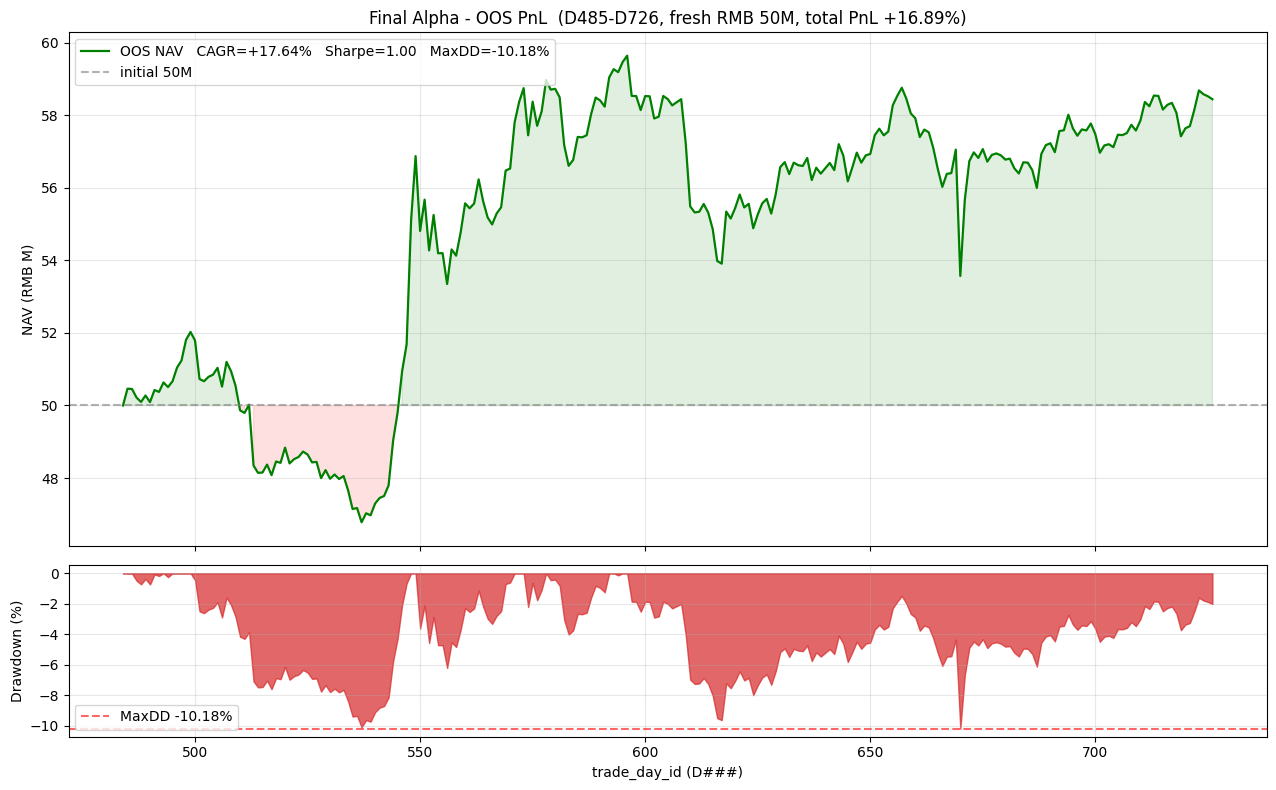

OOS: 50.00M -> 58.44M  |  total PnL +16.89%  |  CAGR +17.64%  Sharpe 1.00  MaxDD -10.18%


In [19]:
import matplotlib.pyplot as plt
# build the OOS equity curve, prepending the 50M starting point at D484
days = oos_nav['day'].values
nav  = oos_nav['nav'].values
x    = np.concatenate([[OOS_START_DAY-1], days])
eq   = np.concatenate([[INITIAL_CAPITAL], nav])
peak = np.maximum.accumulate(eq)
dd   = (eq/peak - 1.0)*100
pnl_pct = (eq[-1]/INITIAL_CAPITAL - 1.0)*100

fig, ax = plt.subplots(2,1, figsize=(13,8), sharex=True, gridspec_kw={'height_ratios':[3,1]})
ax[0].plot(x, eq/1e6, color='green', lw=1.6,
           label=f'OOS NAV   CAGR={cg:+.2%}   Sharpe={sr:.2f}   MaxDD={mdd:+.2%}')
ax[0].axhline(INITIAL_CAPITAL/1e6, color='grey', ls='--', alpha=0.6, label='initial 50M')
ax[0].fill_between(x, INITIAL_CAPITAL/1e6, eq/1e6, where=(eq>=INITIAL_CAPITAL), color='green', alpha=0.12)
ax[0].fill_between(x, INITIAL_CAPITAL/1e6, eq/1e6, where=(eq< INITIAL_CAPITAL), color='red',   alpha=0.12)
ax[0].set_ylabel('NAV (RMB M)')
ax[0].set_title(f'Final Alpha - OOS PnL  (D{OOS_START_DAY}-D{int(days[-1])}, fresh RMB 50M, total PnL {pnl_pct:+.2f}%)')
ax[0].legend(loc='upper left'); ax[0].grid(alpha=0.3)

ax[1].fill_between(x, dd, 0, color='C3', alpha=0.7)
ax[1].axhline(mdd*100, color='red', ls='--', alpha=0.6, label=f'MaxDD {mdd:+.2%}')
ax[1].set_ylabel('Drawdown (%)'); ax[1].set_xlabel('trade_day_id (D###)')
ax[1].legend(loc='lower left'); ax[1].grid(alpha=0.3)
plt.tight_layout()

# export the figure
import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig3_oos_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'OOS: 50.00M -> {eq[-1]/1e6:.2f}M  |  total PnL {pnl_pct:+.2f}%  |  CAGR {cg:+.2%}  Sharpe {sr:.2f}  MaxDD {mdd:+.2%}')